#CargarDATASET de Kaggle


In [ ]:
import pandas as pd

# 1.Cargas el archivo (reemplaza 'nombre_archivo.csv' por el nombre real que descargaste)
df = pd.read_csv('Estudiantes.csv')
#2.traducir y renombrar columnas

df = df.rename(columns={
    'Student_ID': 'ID_Estudiante',
    'Age': 'Edad',
    'Gender': 'Genero',
    'Class': 'Curso_Anio',
    'Study_Hours_Per_Day': 'Horas_Estudio_Por_Dia',
    'Attendance_Percentage': 'Porcentaje_Asistencia',
    'Parental_Education': 'Nivel_Educativo_Padres',
    'Internet_Access': 'Acceso_Internet',
    'Extracurricular_Activities': 'Actividades_Extracurriculares',
    'Math_Score': 'Nota_Matematicas',
    'Science_Score': 'Nota_Ciencias',
    'English_Score': 'Nota_Ingles',
    'Previous_Year_Score': 'Nota_Ano_Anterior',
    'Final_Percentage': 'Porcentaje_Final',
    'Performance_Level': 'Nivel_Rendimiento',
    'Pass_Fail': 'Estado_Aprobacion'
})

# 3. Verificar las dimensiones (filas y columnas)
print("Dimensiones del dataset:", df.shape)

# 4. Ver las primeras filas con los nuevos nombres
print(df.head())

Dimensiones del dataset: (5000, 16)
  ID_Estudiante  Edad  Genero  Curso_Anio  Horas_Estudio_Por_Dia  \
0         S0001    15    Male          12                    1.0   
1         S0002    19  Female           9                    1.6   
2         S0003    14  Female          12                    3.6   
3         S0004    18  Female           9                    5.5   
4         S0005    14    Male          10                    5.0   

   Porcentaje_Asistencia Nivel_Educativo_Padres Acceso_Internet  \
0                     65           Postgraduate              No   
1                     58               Graduate              No   
2                     64            High School             Yes   
3                     68           Postgraduate             Yes   
4                     80            High School             Yes   

  Actividades_Extracurriculares  Nota_Matematicas  Nota_Ciencias  Nota_Ingles  \
0                            No                40             39       

# Modificar DATASET para mi problema


In [ ]:
import pandas as pd
import numpy as np

# 1. Cargar el dataset base original (asegúrate de tener 'Estudiantes.csv' subido en Colab)
df = pd.read_csv('Estudiantes.csv')

# 2. Filtrar mayores de 18 años y tomar una muestra representativa de primer año
df = df[df['Age'] >= 18].copy().head(1500)

# 3. Construir el DataFrame adaptado a tu materia de Informática y Análisis 1
df_nuevo = pd.DataFrame()
df_nuevo['ID_Estudiante'] = df['Student_ID']
df_nuevo['Edad'] = df['Age']
df_nuevo['Genero'] = df['Gender']
df_nuevo['Porcentaje_Asistencia'] = df['Attendance_Percentage']
df_nuevo['Acceso_Internet'] = df['Internet_Access']

np.random.seed(42)
df_nuevo['Tipo_Secundario'] = np.random.choice(['Tecnico', 'No_Tecnico'], size=len(df), p=[0.6, 0.4])
df_nuevo['Nota_Parcial_Informatica'] = np.clip(df['Math_Score'] / 10, 1, 10).round(1)
df_nuevo['Nota_TP_Individual'] = np.clip(df['Science_Score'] / 10, 1, 10).round(1)
df_nuevo['Nota_TP_Grupal'] = np.clip(df['English_Score'] / 10, 1, 10).round(1)

# Incorporamos la nota de Análisis 1 como materia troncal exigente
df_nuevo['Nota_Analisis_1'] = np.clip((df['Math_Score'] * 0.75) / 10, 1, 10).round(1)
df_nuevo['Nota_Legislacion'] = np.clip((df['English_Score'] + 15) / 10, 1, 10).round(1)
df_nuevo['Participacion_Plataforma'] = np.where(df['Internet_Access'] == 'Yes', 'Si', 'No')

# Lógica institucional con las 3 categorías objetivo
def asignar_condicion(row):
    if row['Porcentaje_Asistencia'] < 45 or row['Nota_Analisis_1'] < 4 or (row['Participacion_Plataforma'] == 'No' and row['Nota_Parcial_Informatica'] < 4):
        return 'Abandona'
    elif row['Porcentaje_Asistencia'] >= 75 and row['Nota_Parcial_Informatica'] >= 7 and row['Nota_Analisis_1'] >= 6:
        return 'Promociona'
    else:
        return 'Regulariza'

df_nuevo['Condicion_Final'] = df_nuevo.apply(asignar_condicion, axis=1)

# 4. Guardarlo directo en tu Colab
df_nuevo.to_csv('Estudiantes_Informatica_Analisis.csv', index=False)
print("¡Listo! Archivo 'Estudiantes_Informatica_Analisis.csv' creado con éxito en tu entorno de Colab.")

¡Listo! Archivo 'Estudiantes_Informatica_Analisis.csv' creado con éxito en tu entorno de Colab.


In [ ]:
# 1. Cargamos el archivo que acabamos de crear en Colab
df_nuevo = pd.read_csv('Estudiantes_Informatica_Analisis.csv')

# 2. Ver cuántas filas y columnas tiene (registros y atributos)
print("Dimensiones (Filas, Columnas):", df_nuevo.shape)

# 3. Ver los nombres exactos de todas las columnas
print("\nColumnas del dataset:")
print(df_nuevo.columns.tolist())

# 4. Ver las primeras 5 filas del dataset
print("\nPrimeros registros:")
display(df_nuevo.head())

Dimensiones (Filas, Columnas): (1500, 13)

Columnas del dataset:
['ID_Estudiante', 'Edad', 'Genero', 'Porcentaje_Asistencia', 'Acceso_Internet', 'Tipo_Secundario', 'Nota_Parcial_Informatica', 'Nota_TP_Individual', 'Nota_TP_Grupal', 'Nota_Analisis_1', 'Nota_Legislacion', 'Participacion_Plataforma', 'Condicion_Final']

Primeros registros:


,ID_Estudiante,Edad,Genero,Porcentaje_Asistencia,Acceso_Internet,Tipo_Secundario,Nota_Parcial_Informatica,Nota_TP_Individual,Nota_TP_Grupal,Nota_Analisis_1,Nota_Legislacion,Participacion_Plataforma,Condicion_Final
0,S0002,19,Female,58,No,Tecnico,8.0,4.4,3.5,6.0,5.0,No,Regulariza
1,S0004,18,Female,68,Yes,No_Tecnico,6.8,4.8,7.7,5.1,9.2,Si,Regulariza
2,S0006,19,Male,82,No,No_Tecnico,8.8,7.0,4.6,6.6,6.1,No,Promociona
3,S0008,18,Female,81,No,Tecnico,9.3,3.7,4.8,7.0,6.3,No,Promociona
4,S0009,18,Female,61,No,Tecnico,5.5,3.9,8.3,4.1,9.8,No,Regulariza


# Limpiar DATASET(EDA)

In [ ]:
# Exploramos el dataset (EDA) Ver tipos de datos y si hay valores nulos
print(df_nuevo.info())
# Ver si hay valores nulos en alguna columna
print("\nValores nulos por columna:")
print(df_nuevo.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID_Estudiante             1500 non-null   object 
 1   Edad                      1500 non-null   int64  
 2   Genero                    1500 non-null   object 
 3   Porcentaje_Asistencia     1500 non-null   int64  
 4   Acceso_Internet           1500 non-null   object 
 5   Tipo_Secundario           1500 non-null   object 
 6   Nota_Parcial_Informatica  1500 non-null   float64
 7   Nota_TP_Individual        1500 non-null   float64
 8   Nota_TP_Grupal            1500 non-null   float64
 9   Nota_Analisis_1           1500 non-null   float64
 10  Nota_Legislacion          1500 non-null   float64
 11  Participacion_Plataforma  1500 non-null   object 
 12  Condicion_Final           1500 non-null   object 
dtypes: float64(5), int64(2), object(6)
memory usage: 152.5+ KB
None

# Calcular Totales por VAR objetivo(clases )


In [ ]:
# Ver la distribución absoluta y porcentual de la condición final
print("Cantidad de alumnos por categoría:")
print(df_nuevo['Condicion_Final'].value_counts())

print("\nPorcentaje de alumnos por categoría:")
print(df_nuevo['Condicion_Final'].value_counts(normalize=True) * 100)


Cantidad de alumnos por categoría:
Condicion_Final
Regulariza    874
Abandona      359
Promociona    267
Name: count, dtype: int64

Porcentaje de alumnos por categoría:
Condicion_Final
Regulariza    58.266667
Abandona      23.933333
Promociona    17.800000
Name: proportion, dtype: float64


# Separar varX(features) varY(target)

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Copiamos el dataframe para no alterar el original
df_model = df_nuevo.copy()

# 1. Codificar las variables categóricas de texto a números
categorical_cols = ['Genero', 'Tipo_Secundario', 'Acceso_Internet', 'Participacion_Plataforma']
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])

# 2. Separar las Features (X - variables predictoras) del Target (y - lo que queremos predecir)
# Quitamos el ID_Estudiante porque no aporta valor predictivo al modelo
X = df_model.drop(columns=['ID_Estudiante', 'Condicion_Final'])
y = df_model['Condicion_Final']

print("Features (X) listas con formas:", X.shape)
print("Target (y) listo con clases:", y.unique())

Features (X) listas con formas: (1500, 11)
Target (y) listo con clases: ['Regulariza' 'Promociona' 'Abandona']


# dividir 80/20 datos para entrenar y test

In [ ]:
#separasmo 80 % paar entrenatr y 20% para test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Comprobamos que se haya dividido correctamente
print(f"Total de alumnos para entrenar (X_train): {X_train.shape[0]} filas")
print(f"Total de alumnos para evaluar (X_test): {X_test.shape[0]} filas")

Total de alumnos para entrenar (X_train): 1200 filas
Total de alumnos para evaluar (X_test): 300 filas


# Agregar nuevos datos porque el modelo dio una accuracy del 100% .

In [ ]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Entrenar y evaluar Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("--- MODELO 1: RANDOM FOREST ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%\n")
print("Reporte de Clasificación (RF):")
print(classification_report(y_test, y_pred_rf))

print("="*50)

# 2. Entrenar y evaluar AdaBoost
ada_model = AdaBoostClassifier(random_state=42)
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)

print("\n--- MODELO 2: ADABOOST ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ada) * 100:.2f}%\n")
print("Reporte de Clasificación (AdaBoost):")
print(classification_report(y_test, y_pred_ada))

--- MODELO 1: RANDOM FOREST ---
Accuracy: 100.00%

Reporte de Clasificación (RF):
              precision    recall  f1-score   support

    Abandona       1.00      1.00      1.00        82
  Promociona       1.00      1.00      1.00        58
  Regulariza       1.00      1.00      1.00       160

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300


--- MODELO 2: ADABOOST ---
Accuracy: 100.00%

Reporte de Clasificación (AdaBoost):
              precision    recall  f1-score   support

    Abandona       1.00      1.00      1.00        82
  Promociona       1.00      1.00      1.00        58
  Regulariza       1.00      1.00      1.00       160

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



# Correr dos modelos para compararlos


In [ ]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# 1. Copiamos el dataframe
df_model = df_nuevo.copy()

# 2. Introducimos el 10% de ruido en la variable objetivo
np.random.seed(42)
mask = np.random.rand(len(df_model)) < 0.10
clases_posibles = ['Abandona', 'Regulariza', 'Promociona']

for idx in np.where(mask)[0]:
  current = df_model.loc[idx, 'Condicion_Final']
  otras_clases = [c for c in clases_posibles if c != current]
  df_model.loc[idx, 'Condicion_Final'] = np.random.choice(otras_clases)

# 3. ¡VOLVEMOS A CONVERTIR EL TEXTO A NÚMEROS! (LabelEncoder)
categorical_cols = [
    'Genero',
    'Tipo_Secundario',
    'Acceso_Internet',
    'Participacion_Plataforma',
]
for col in categorical_cols:
  le = LabelEncoder()
  df_model[col] = le.fit_transform(df_model[col])

# 4. Definimos X e y ya limpios y numéricos
X = df_model.drop(columns=['ID_Estudiante', 'Condicion_Final'])
y = df_model['Condicion_Final']

# 5. Dividimos en Train y Test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("--- MODELO 1: RANDOM FOREST (Con datos reales/ruidosos) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%\n")
print(classification_report(y_test, y_pred_rf))

print("=" * 50)

# 2. AdaBoost
ada_model = AdaBoostClassifier(random_state=42)
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)

print("\n--- MODELO 2: ADABOOST (Con datos reales/ruidosos) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ada) * 100:.2f}%\n")
print(classification_report(y_test, y_pred_ada))

--- MODELO 1: RANDOM FOREST (Con datos reales/ruidosos) ---
Accuracy: 86.67%

              precision    recall  f1-score   support

    Abandona       0.95      0.80      0.87        97
  Promociona       0.83      0.79      0.81        63
  Regulariza       0.84      0.94      0.89       140

    accuracy                           0.87       300
   macro avg       0.87      0.85      0.86       300
weighted avg       0.87      0.87      0.87       300


--- MODELO 2: ADABOOST (Con datos reales/ruidosos) ---
Accuracy: 87.00%

              precision    recall  f1-score   support

    Abandona       0.95      0.79      0.87        97
  Promociona       0.85      0.79      0.82        63
  Regulariza       0.84      0.96      0.89       140

    accuracy                           0.87       300
   macro avg       0.88      0.85      0.86       300
weighted avg       0.88      0.87      0.87       300



# Matriz de confusion

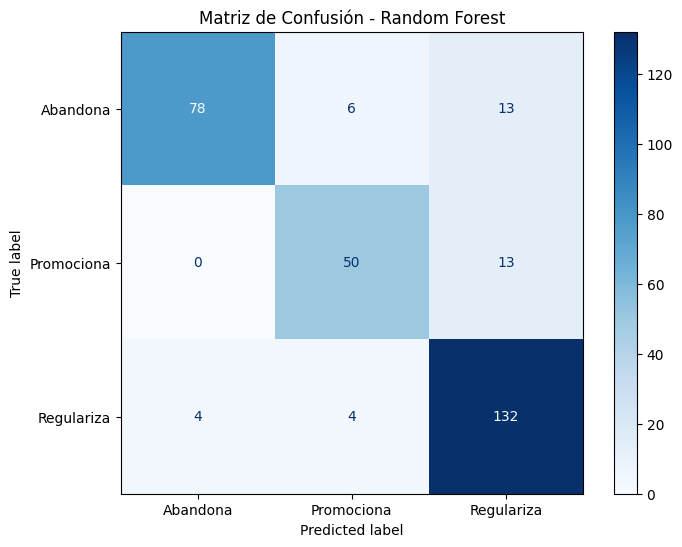

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Generar y mostrar la matriz de confusión para Random Forest
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    display_labels=['Abandona', 'Promociona', 'Regulariza'],
    cmap=plt.cm.Blues,
    ax=ax,
)
plt.title('Matriz de Confusión - Random Forest')
plt.show()

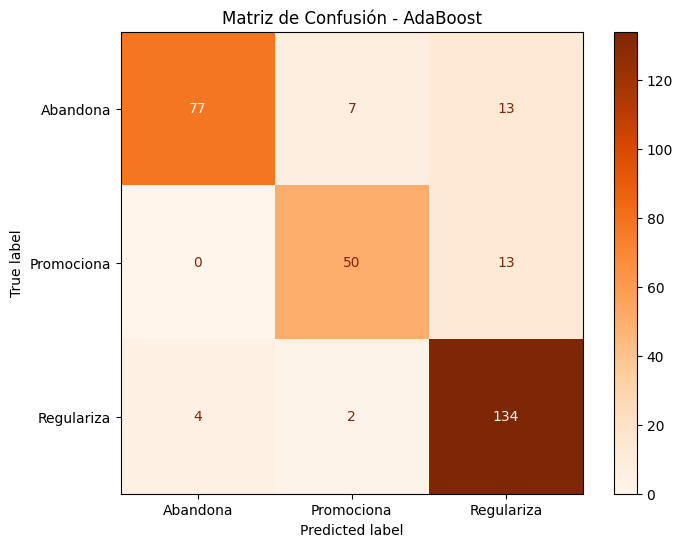

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Generar y mostrar la matriz de confusión para AdaBoost
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    ada_model,  # Usamos el modelo AdaBoost
    X_test,
    y_test,
    display_labels=['Abandona', 'Promociona', 'Regulariza'],
    cmap=plt.cm.Oranges,  # Usamos tonos naranjas para diferenciarlo del de Random Forest
    ax=ax,
)
plt.title('Matriz de Confusión - AdaBoost')
plt.show()